2/6/2026

e4MSTP samples for ViT model (300 px)

- e4MSTP was saved as 8bit, transform it to ML ready format
- for ViT (run 2) I have created a new e4MSTP layer with wrong code, I will need to re-process it again, but we can do that later
- now use existing 8bit file and retrain the ViT
- the grid was already created for previous run (with wrong values for e4MSTP), reuse that one

# Creating a learning dataset for STONE project
---
```
Author: Nejc Čož
Mail: nejc.coz@zrc-sazu.si
Organisation: ZRC SAZU
Ljubljana, 2026
```
---


## Imports

In [5]:
from matplotlib import pyplot as plt
import geopandas as gpd
import pathlib

## 1. Tiles (vector footprints)

The first step is to define the learning dataset. This requires **three vector inputs**:

1. **Data extent polygon**
   A polygon defining the geographical extent of the area for which the DEM/DFM is available.

2. **Archaeology reference layer**
   A vector layer containing known archaeological features. This layer acts as the *positive mask* for creating learning samples.

3. **Dataset split layer (training / validation / test)**
   A vector layer containing rectangular polygons that define areas reserved for *validation* and *test* samples.
   All areas not covered by these polygons are automatically assigned to the *training* set.

Before starting, decide how the data will be divided between training, validation, and test subsets. A typical split is approximately:

* **60 % training**
* **20 % validation**
* **20 % test**

The exact proportions may vary depending on data availability and study design.

> **Important**
> In the split vector file, each polygon **must** have a string attribute named `split` with one of the following values:
>
> * `"validation"`
> * `"test"`
>
> No explicit `"training"` label is required; any area not covered by validation or test polygons is implicitly treated as training data.



In [3]:
# Define paths to input files

extents_file = r"r:\ML podatki\gis_data\ALS_2025_SLRM_footprint.gpkg"

archaeology_file = r"r:\ML podatki\archaeology\gomile_2025-01-16.gpkg"

split_file = r"r:\ML podatki\learning_samples\ml_dataset_split_300px.gpkg"


---

### Visualise input data

At this stage, it is good practice to visualise the input data to verify that everything is correctly prepared and spatially aligned. The resulting figure should resemble the example shown here.

2026-05-31 18:21:44,778 ERROR PROJ: proj_identify: Cannot find proj.db
2026-05-31 18:21:45,417 ERROR PROJ: proj_identify: Cannot find proj.db
2026-05-31 18:21:46,963 ERROR PROJ: proj_identify: Cannot find proj.db


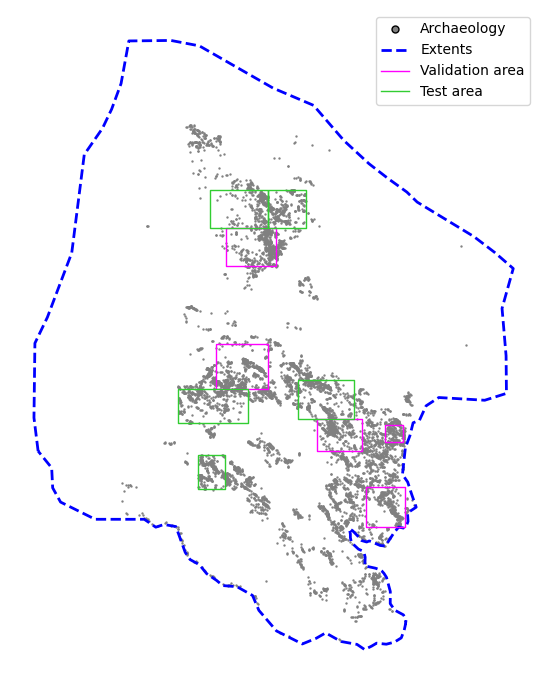

In [9]:
from matplotlib.lines import Line2D

# Load input data and visualize
gdf_extents = gpd.read_file(extents_file)
gdf_archaeology = gpd.read_file(archaeology_file)
gdf_archaeology = gdf_archaeology[gdf_archaeology.geometry.within(gdf_extents.iloc[0].geometry)].copy()
gdf_split = gpd.read_file(split_file)

fig, ax = plt.subplots(1, 1, figsize=(7, 7)) 
gdf_archaeology.centroid.plot(color='gray', markersize=0.5, ax=ax)
gdf_extents.plot(facecolor="none", edgecolor='blue', linewidth=2, linestyle='--', ax=ax)
gdf_split[gdf_split["split"] == "validation"].plot(column='split', facecolor="none", edgecolor='magenta', linewidth=1, ax=ax)
gdf_split[gdf_split["split"] == "test"].plot(column='split', facecolor="none", edgecolor='limegreen', linewidth=1, ax=ax)

# Legend 
legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='gray', markersize=5, label='Archaeology'),
    Line2D([0], [0], color='blue', linestyle='--', linewidth=2, label='Extents'),
    Line2D([0], [0], color='magenta', linewidth=1, label='Validation area'),
    Line2D([0], [0], color='limegreen', linewidth=1, label='Test area'),
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True)

# Remove axis labels and ticks
ax.set_axis_off()

plt.tight_layout()
plt.show()


---

### Tile generation

In [6]:
# Define location of the main output folder
output_folder = r"r:\ML podatki\learning_samples\vit_300px_e4mstp"
output_folder = pathlib.Path(output_folder)
output_folder.mkdir(parents=True, exist_ok=True)

# Additional requiered parameters
tile_size = 300
tile_overlap = 0
pixel_size = 0.5

In [6]:
from adaf.create_singleclass_dataset import build_singleclass_segmentation_grids

tiles_gdf = build_singleclass_segmentation_grids(
    extents_gdf=gdf_extents,
    archaeology_gdf=gdf_archaeology,
    split_gdf=gdf_split,
    class_name="barrow",
    tile_size_px=tile_size,
    overlap_px=tile_overlap,
    pixel_size=pixel_size,
    split_field="split",
)

print(tiles_gdf["split"].value_counts().reindex(["training", "validation", "test"], fill_value=0))

split
training      3186
validation    1226
test          8266
Name: count, dtype: int64


In [10]:
# You can save the tiles to a vector file for later use
gdf_path = pathlib.Path(r"r:\ML podatki\learning_samples\vit_300px_e4mstp\learning_dataset_tiles.gpkg")
tiles_gdf.to_file(r"r:\ML podatki\learning_samples\vit_300px_e4mstp\learning_dataset_tiles.gpkg", driver="GPKG")  


### Output of the tile generation step

Using the three vector inputs listed above, the code generates a new vector layer `tiles_gdf` containing the **footprints of all learning tiles**.

The code automatically generates:
- the dataset split labels (*train / validation / test*).

---

### Visualise patches footprints

We can again visualise footprints, to see if tiles were created correctly.

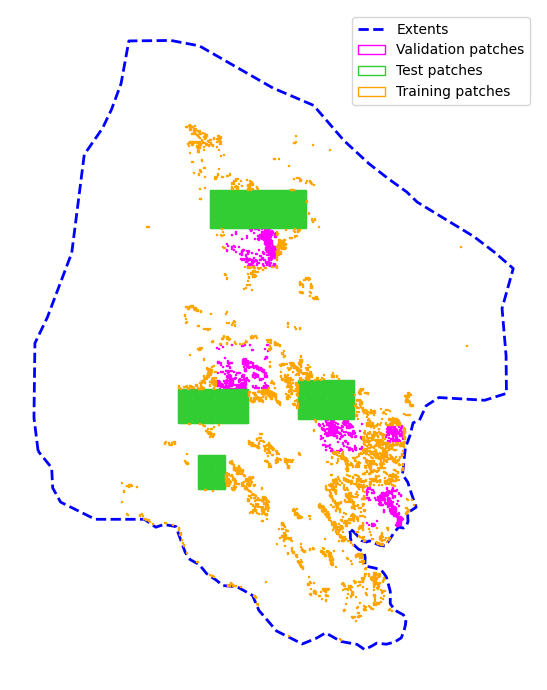

In [11]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


fig, ax = plt.subplots(1, 1, figsize=(7, 7)) 
gdf_extents.plot(facecolor="none", edgecolor='blue', linewidth=2, linestyle='--', ax=ax)
tiles_gdf[tiles_gdf["split"] == "validation"].plot(column='split', facecolor="none", edgecolor='magenta', linewidth=1, ax=ax)
tiles_gdf[tiles_gdf["split"] == "test"].plot(column='split', facecolor="none", edgecolor='limegreen', linewidth=1, ax=ax)
tiles_gdf[tiles_gdf["split"] == "training"].plot(column='split', facecolor="none", edgecolor='orange', linewidth=1, ax=ax)


# Legend 
legend_elements = [
    Line2D([0], [0], color='blue', linestyle='--', linewidth=2, label='Extents'),
    Patch(facecolor="none", edgecolor="magenta", label="Validation patches"),
    Patch(facecolor="none", edgecolor="limegreen", label="Test patches"),
    Patch(facecolor="none", edgecolor="orange", label="Training patches")
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True)

# Remove axis labels and ticks
ax.set_axis_off()

plt.tight_layout()
plt.show()


---

## 2. Create visualisation

Visualisations already created and is saved on disk (can be loaded from disk).

---

## 3. Create patches

The next step is to run the processing that creates the training patches.


**Requiered inputs**
* the visualisation raster `visualisation_ds_pth` created in **Section 2**
* the tile grid `tiles_gdf` created in **Step 1**

The only additional requirement is to specify the output location where the learning dataset will be saved. We will use the root folder `output_folder` that was defined at the begining of the notebook.

If the tile grid `tiles_gdf` has already been created in a previous run, it can be loaded directly from disk

```python
tiles_gdf = gpd.read_file(r"<path/to/file.gpkg>")
```

Before we start making ML patches, we need to generate file paths (in `tiles_gdf`) for saving the image tiles and their corresponding segmentation masks.

In [1]:
# Optional import of tiles, if we have them saved in a vector file

import geopandas as gpd

tiles_gdf = gpd.read_file(r"r:\ML podatki\learning_samples\vit_300px_e4mstp\learning_dataset_tiles.gpkg")

In [2]:
tiles_gdf.head()

,split,class,tile_id,geometry
0,training,barrow,254250_4754700,"POLYGON ((254400.000 4754850.000, 254400.000 4..."
1,training,barrow,254250_4752000,"POLYGON ((254400.000 4752150.000, 254400.000 4..."
2,training,barrow,254550_4753650,"POLYGON ((254700.000 4753800.000, 254700.000 4..."
3,training,barrow,254550_4753500,"POLYGON ((254700.000 4753650.000, 254700.000 4..."
4,training,barrow,254850_4754250,"POLYGON ((255000.000 4754400.000, 255000.000 4..."


In [7]:
from adaf.create_singleclass_dataset import add_image_and_mask_paths

# Location to which we want to save learning data
output_directory = output_folder  #  r"r:\ML podatki\learning_samples\vit_300px"

# Name of the "project" - recommend using the stem of the input raster name (for example: ALS_stone_2025.vrt -> ALS_stone_2025)
ds_name = "e4mstp_float"

tiles_gdf = add_image_and_mask_paths(
    tiles_gdf,
    output_root=output_directory,
    ds_name=ds_name
)

print("Example of save paths for image and mask:")
print(tiles_gdf.iloc[0]["images_path"])
print(tiles_gdf.iloc[0]["segmentation_masks_path"])

Example of save paths for image and mask:
r:/ML podatki/learning_samples/vit_300px_e4mstp/training/images/254250_4754700__e4mstp_float__images.tif
r:/ML podatki/learning_samples/vit_300px_e4mstp/training/segmentation_masks/254250_4754700__e4mstp_float__segmentation_masks.tif


In [10]:
from pathlib import Path
from adaf.create_singleclass_dataset import (
    add_image_and_mask_paths_png,
    create_samples_for_vit,
)

# Location to which we want to save learning data
output_directory = output_folder  #  r"r:\ML podatki\learning_samples\vit_300px"

# Name of the "project" - recommend using the stem of the input raster name (for example: ALS_stone_2025.vrt -> ALS_stone_2025)
ds_name = "e4mstp_float"

# gdf_tiles must contain: geometry + split + tile_id
# (e.g. produced by build_singleclass_segmentation_grids)
gdf_tiles = add_image_and_mask_paths_png(
    tiles_grid=tiles_gdf,
    output_root=Path(output_directory),
    ds_name=ds_name,
)

input_raster = r"r:\BiH_ALS_2025\e4MSTP_float2.vrt"

# gdf_archaeology = polygons for barrows (same CRS as raster/tiles)
results = create_samples_for_vit(
    gdf_tiles=gdf_tiles,
    gdf_archaeology=gdf_archaeology,
    input_raster=Path(input_raster),
    arch_type="barrow",
)

# results is a list of (image_png_path, mask_png_path)
